# Semana 02 - INTI6 - Atividade




---


**Machine Learning**

Tecnologia em Análise e Desenvolvimento de Sistemas

Instituto Federal de Mato Grosso do Sul - Câmpus Três Lagoas

Prof. Carlos R Santos Jr

1° Semestre de 2026

---



# Instruções

Implemente um modelo de ML para identificar e-mails do tipo SPAMS.
Utilize **Árvore de Decisão** para construir seu classificador.


## Preparação do ambiente

Execute esta célula antes das tarefas. Ela instala no kernel atual apenas as bibliotecas que ainda não estiverem disponíveis.

In [1]:
import importlib.util
import subprocess
import sys

dependencias = {
    "pandas": "pandas>=2.2,<3.0",
    "sklearn": "scikit-learn>=1.5,<2.0",
    "matplotlib": "matplotlib>=3.9,<4.0",
}

pacotes_ausentes = [
    pacote
    for modulo, pacote in dependencias.items()
    if importlib.util.find_spec(modulo) is None
]

if pacotes_ausentes:
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        *pacotes_ausentes,
    ])
    print("Dependências instaladas no kernel atual.")
else:
    print("Todas as dependências já estão instaladas.")

Dependências instaladas no kernel atual.


## Tarefa 01 - Leitura da base de dados

 Faça a leitura da base de dados **emails.csv**.

Trata-se de um base de dados formada com informações de 4.000 e-mails. Cada linha da base de dados representa 1 (um) e-mail específico e cada coluna representa uma palavra comum entre os e-mails.
As informações em  formato numérico representam a quantidade de vezes que uma determinada palavra (coluna) aparece em um e-mail.

O dataset é resultado de um Processamento de Linguagem Natural (PLN), responsável por preparar textos (e-mails, artigos, etc.) através da remoção de informações irrelevantes e quantificação das informações relevantes. Dessa forma, é possível o uso dessas informações em modelos de ML.    

Link:https://raw.githubusercontent.com/CarlosR-SantosJr/DisciplinaInteligenciaArtificial-INTI6/main/datasets/emails.csv

In [2]:
import pandas as pd

url = "https://raw.githubusercontent.com/CarlosR-SantosJr/DisciplinaInteligenciaArtificial-INTI6/main/datasets/emails.csv"

# A primeira coluna do arquivo contém apenas o identificador numérico do e-mail.
emails = pd.read_csv(url, index_col=0)

print(f"Dimensões da base: {emails.shape[0]} e-mails e {emails.shape[1]} colunas")
display(emails.head())

print("\nDistribuição da variável-alvo (0 = não spam; 1 = spam):")
display(emails["Prediction"].value_counts().sort_index().rename("quantidade"))

Dimensões da base: 4000 e-mails e 3001 colunas


,the,to,ect,and,for,of,a,you,hou,in,...,connevey,jay,valued,lay,infrastructure,military,allowing,ff,dry,Prediction
0,0,0,1,0,0,0,2,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,8,13,24,6,6,2,102,1,27,18,...,0,0,0,0,0,0,0,1,0,0
2,0,0,1,0,0,0,8,0,0,4,...,0,0,0,0,0,0,0,0,0,0
3,0,5,22,0,5,1,51,2,10,1,...,0,0,0,0,0,0,0,0,0,0
4,7,6,17,1,5,2,57,0,9,3,...,0,0,0,0,0,0,0,1,0,0



Distribuição da variável-alvo (0 = não spam; 1 = spam):


Prediction
0    2860
1    1140
Name: quantidade, dtype: int64

## Tarefa 02 - Divisão da base de dados (Treino/Teste)


In [3]:
from sklearn.model_selection import train_test_split

# X contém as palavras (variáveis explicativas) e y contém a classe do e-mail.
X = emails.drop(columns="Prediction")
y = emails["Prediction"]

# Separamos 20% para teste. O stratify preserva a proporção de spam nas duas partes.
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

print(f"Amostras de treino: {X_treino.shape[0]}")
print(f"Amostras de teste:  {X_teste.shape[0]}")

Amostras de treino: 3200
Amostras de teste:  800


## Tarefa 03 - Treino

In [4]:
from sklearn.tree import DecisionTreeClassifier

# O random_state torna o treinamento reproduzível.
modelo = DecisionTreeClassifier(random_state=42)
modelo.fit(X_treino, y_treino)

print(f"Modelo treinado com {modelo.get_depth()} níveis e {modelo.get_n_leaves()} folhas.")

Modelo treinado com 37 níveis e 137 folhas.


## Tarefa 04 - Teste (Predição)

In [5]:
y_predito = modelo.predict(X_teste)

# Visualização de algumas classificações feitas pelo modelo.
comparacao = pd.DataFrame({
    "classe_real": y_teste.to_numpy(),
    "classe_predita": y_predito,
}, index=y_teste.index)

display(comparacao.head(10))

,classe_real,classe_predita
2488,0,0
3582,0,0
614,1,1
3150,0,0
156,0,0
1224,0,0
3076,0,0
1577,0,0
2673,0,0
2338,0,0


## Tarefa 05 - Avaliação do Modelo

Acurácia no treino: 100.00%
Acurácia no teste:  91.50%

Relatório de classificação:
              precision    recall  f1-score   support

    Não spam      0.929     0.955     0.941       572
        Spam      0.877     0.816     0.845       228

    accuracy                          0.915       800
   macro avg      0.903     0.885     0.893       800
weighted avg      0.914     0.915     0.914       800



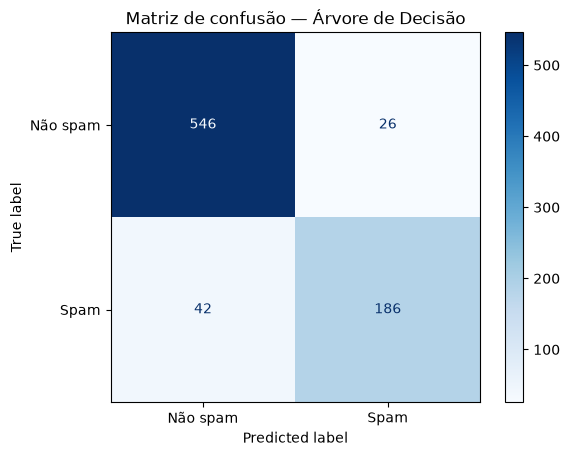

In [6]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
)

acuracia_treino = accuracy_score(y_treino, modelo.predict(X_treino))
acuracia_teste = accuracy_score(y_teste, y_predito)

print(f"Acurácia no treino: {acuracia_treino:.2%}")
print(f"Acurácia no teste:  {acuracia_teste:.2%}\n")
print("Relatório de classificação:")
print(classification_report(
    y_teste,
    y_predito,
    target_names=["Não spam", "Spam"],
    digits=3,
))

matriz = confusion_matrix(y_teste, y_predito)
visualizacao = ConfusionMatrixDisplay(
    confusion_matrix=matriz,
    display_labels=["Não spam", "Spam"],
)
visualizacao.plot(cmap="Blues", values_format="d")
plt.title("Matriz de confusão — Árvore de Decisão")
plt.show()